In [ ]:
! pip install --upgrade keras

In [ ]:
! pip install numpy opencv-python imgaug

In [ ]:
import os
import cv2

os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
from keras import ops

import numpy as np
import matplotlib.pyplot as plt


## Dataset

In [ ]:
def read_images_from_folder(folder_path, image_height, image_width):
    images = []
    labels = []
    label_to_index = {}  # Map label names to numerical indices
    index = 0

    for category in os.listdir(folder_path):
        label_to_index[category] = index
        category_folder = os.path.join(folder_path, category)

        if os.path.isdir(category_folder):
            for filename in os.listdir(category_folder):
                try:
                    image_path = os.path.join(category_folder, filename)
                    image = cv2.imread(image_path)
                    image = cv2.resize(image, (image_height, image_width))  # Resize image to desired dimensions
                    images.append(image)
                    labels.append(index)
                except:
                    print(filename)
        index += 1

    images = np.array(images)
    labels = np.array(labels)

    return images, labels, label_to_index

In [ ]:
folder_path = "/content/drive/MyDrive/pose Estimation"
# folder_path_test = "/home/somesh/Documents/datasets/my_data/test"
image_height = 32
image_width = 32

X, y, label_to_index = read_images_from_folder(folder_path, image_height, image_width)
# X_val, y_val, label_to_index = read_images_from_folder(folder_path_test, image_height, image_width)

print("Number of images:", len(X))
print("Number of labels:", len(y))
print("Label to index mapping:", label_to_index)

Number of images: 427
Number of labels: 427
Label to index mapping: {'Squating': 0, 'Bending': 1, 'Standing': 2}


In [ ]:
import numpy as np

y = np.reshape(y, (-1, 1))

## Prepare the data

In [ ]:
from sklearn.model_selection import train_test_split

# using the train test split function
x_train, x_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=104,
                                   test_size=0.25,
                                   shuffle=True)

In [ ]:
num_classes = 3
input_shape = (32, 32, 3)

## Configure the hyperparameters

In [ ]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 10
num_epochs = 10  # For real training, use num_epochs=100. 10 is a test value
image_size = 72  # We'll resize input images to this size
patch_size = 6  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]  # Size of the dense layers of the final classifie

## Use Data Augmentation

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(x_train)


## Implement multilayer Perceptron (MLP)

In [ ]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


## Implement patch creation as a layer

In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


Image size: 72 X 72
Patch size: 6 X 6
Patches per image: 144
Elements per patch: 108


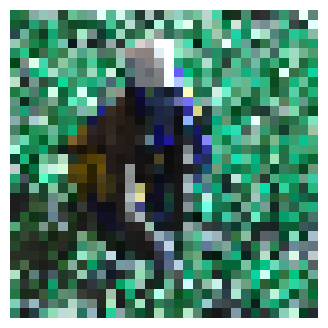

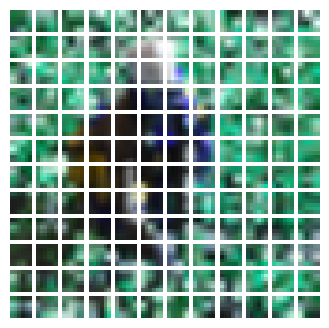

In [ ]:
plt.figure(figsize=(4, 4))
image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image.astype("uint8"))
plt.axis("off")

resized_image = ops.image.resize(
    ops.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")


## Implement the patch encoding layer

The PatchEncoder layer will linearly transform a patch by projecting it into a vector of size projection_dim. In addition, it adds a learnable position embedding to the projected vector.

In [ ]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config


## Build the ViT Model

The ViT model consists of multiple Transformer blocks, which use the layers.MultiHeadAttention layer as a self-attention mechanism applied to the sequence of patches. The Transformer blocks produce a [batch_size, num_patches, projection_dim] tensor, which is processed via an classifier head with softmax to produce the final class probabilities output.

Unlike the technique described in the paper, which prepends a learnable embedding to the sequence of encoded patches to serve as the image representation, all the outputs of the final Transformer block are reshaped with layers.Flatten() and used as the image representation input to the classifier head. Note that the layers.GlobalAveragePooling1D layer could also be used instead to aggregate the outputs of the Transformer block, especially when the number of patches and the projection dimensions are large.

In [ ]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model


## Compile, train, and evluate the model

In [ ]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)


def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")
plot_history("top-5-accuracy")


ValueError: k argument to top_k must be no larger than minor dimension; 5 vs [10, 3]

In [ ]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

# def plot_history(item):
#     plt.plot(history.history[item], label=item)
#     plt.plot(history.history["val_" + item], label="val_" + item)
#     plt.xlabel("Epochs")
#     plt.ylabel(item)
#     plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
#     plt.legend()
#     plt.grid()
#     plt.show()


# plot_

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.5220 - loss: 4.7328 - val_accuracy: 0.7500 - val_loss: 2.6705
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7685 - loss: 3.0669 - val_accuracy: 0.8750 - val_loss: 1.8931
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7884 - loss: 3.0894 - val_accuracy: 0.8438 - val_loss: 1.7001
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8576 - loss: 0.9157 - val_accuracy: 0.8438 - val_loss: 1.1477
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7920 - loss: 2.1966 - val_accuracy: 0.9062 - val_loss: 0.3548
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8458 - loss: 1.0755 - val_accuracy: 0.9062 - val_loss: 0.5108
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9184 - loss: 0.5723 - val_accuracy: 0.9375 - val_loss: 0.3762
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9181 - loss: 0.7010 - val_accuracy: 0.8438 - val_loss:

In [ ]:
def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

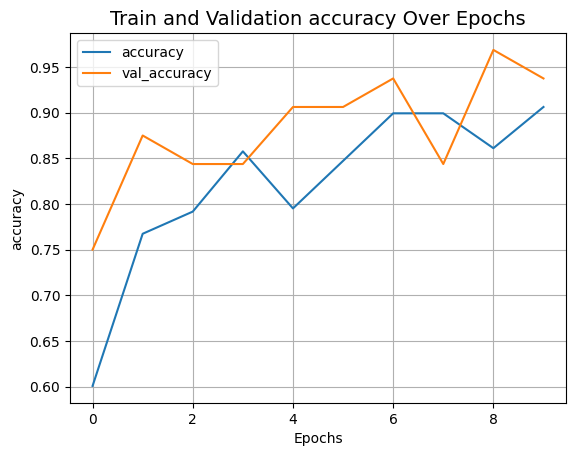

In [ ]:
plot_history("accuracy")

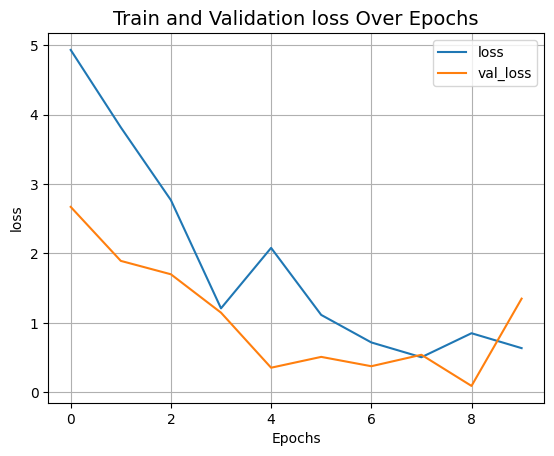

In [ ]:
plot_history("loss")

In [ ]:
from sklearn.metrics import confusion_matrix

# Make predictions on the test data
y_pred = vit_classifier.predict(x_test)

print(y_pred)
# # Generate the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Print the confusion matrix
# print(cm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step
[[  5.1848884   -0.6273092   -2.6890197 ]
 [ -5.868554   -27.122795    22.45777   ]
 [ -3.7549913  -17.352142    13.955939  ]
 [ -6.0177417  -34.39335     22.712797  ]
 [ -4.176336    -7.3811655    3.4751847 ]
 [-11.150487   -11.930254    10.976017  ]
 [-25.474127   -24.928963    23.187859  ]
 [ 15.377462   -10.461131    -2.3123963 ]
 [-15.047841   -30.654964    31.434637  ]
 [-21.355818   -29.830133    26.28749   ]
 [  9.32286     -6.6605453   -1.8745012 ]
 [ -2.9027047  -18.625668    13.910816  ]
 [-16.783152    -5.5102096    9.261047  ]
 [ -3.7971323  -16.571033     9.987049  ]
 [ -7.350822    -2.4273825    3.820508  ]
 [  2.2690635  -13.178082     5.7594094 ]
 [  3.8284724  -14.7210045    9.9326105 ]
 [  9.920742    -5.0801783   -3.3140345 ]
 [-10.764759   -12.3284025   11.800133  ]
 [  2.1960723    2.459584    -4.4574013 ]
 [ -6.6589737  -39.15596     25.42666   ]
 [ -8.630804   -31.7204      20.7847    ]
 [  3.284071   -14.17088      5.35115

NameError: name 'cm' is not defined